<a href="https://colab.research.google.com/github/Zekaiiz/MSSP-6070-Zekai-Zhang/blob/main/PARTICIPATION_ACTIVITY_Week_8_Plot_a_trendline_over_a_time_series_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('InternetSales.csv', encoding='latin1')

Saving InternetSales.csv to InternetSales.csv


/tmp/ipython-input-1774824020.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('InternetSales.csv', encoding='latin1')


In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [8]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly = df.set_index("OrderDate")["SalesAmount"].resample("MS").sum()

X = np.arange(len(monthly)).reshape(-1, 1)
y = monthly.values
model = LinearRegression().fit(X, y)


In [12]:
h = 60
future_idx = np.arange(len(monthly), len(monthly) + h).reshape(-1, 1)
pred = model.predict(future_idx)
future_dates = pd.date_range(monthly.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

In [15]:
future_months = 60
future_X = np.arange(len(monthly), len(monthly) + future_months).reshape(-1, 1)
future_predictions = model.predict(future_X)

future_dates = pd.date_range(start=monthly.index[-1] + pd.DateOffset(months=1),
                             periods=future_months, freq="MS")

forecast_df = pd.DataFrame({"ForecastedSales": future_predictions}, index=future_dates)
print(forecast_df)

            ForecastedSales
2014-02-01     1.326400e+06
2014-03-01     1.354800e+06
2014-04-01     1.383200e+06
2014-05-01     1.411600e+06
2014-06-01     1.440001e+06
2014-07-01     1.468401e+06
2014-08-01     1.496801e+06
2014-09-01     1.525201e+06
2014-10-01     1.553601e+06
2014-11-01     1.582001e+06
2014-12-01     1.610402e+06
2015-01-01     1.638802e+06
2015-02-01     1.667202e+06
2015-03-01     1.695602e+06
2015-04-01     1.724002e+06
2015-05-01     1.752402e+06
2015-06-01     1.780802e+06
2015-07-01     1.809203e+06
2015-08-01     1.837603e+06
2015-09-01     1.866003e+06
2015-10-01     1.894403e+06
2015-11-01     1.922803e+06
2015-12-01     1.951203e+06
2016-01-01     1.979604e+06
2016-02-01     2.008004e+06
2016-03-01     2.036404e+06
2016-04-01     2.064804e+06
2016-05-01     2.093204e+06
2016-06-01     2.121604e+06
2016-07-01     2.150005e+06
2016-08-01     2.178405e+06
2016-09-01     2.206805e+06
2016-10-01     2.235205e+06
2016-11-01     2.263605e+06
2016-12-01     2.292

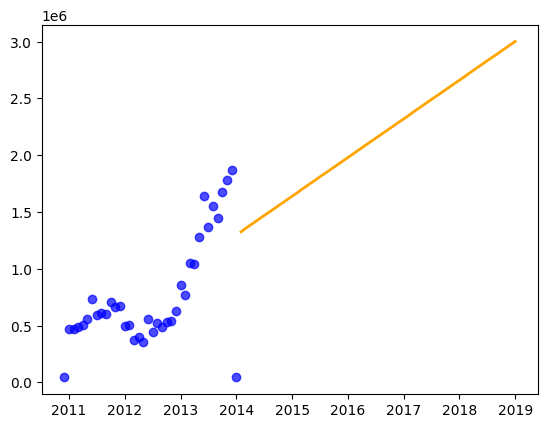

In [10]:
plt.scatter(monthly.index, monthly.values, color='blue', label='Actual Monthly Sales', alpha=0.7)
plt.plot(future_dates, pred, color='orange', linewidth=2.0, label='Forecast (Next 60 Months)')
plt.show()

In [16]:
product_sales = df.groupby('EnglishProductName')['SalesAmount'].sum()

most_sales_product = product_sales.idxmax()
sales_amount = product_sales.max()

print(f"The product with the most sales: {most_sales_product}")

The product with the most sales: Mountain-200 Black, 46
